# Can two identical emitter types be told apart?

Every synthetic emitter sends **QPSK**. Only its fixed hardware imperfections differ. We compare a conventional real CNN (I and Q as two channels) with a similarly sized complex CNN that processes IQ natively.

| Fingerprint | Physical source |
|---|---|
| IQ gain/phase imbalance | imperfect quadrature mixer |
| phase noise | local oscillator |
| amplifier distortion | transmitter power amplifier |

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA

from evaluation import emitter_metrics, open_set_auroc, predictions
from models import ComplexEncoder, EmitterClassifier, RealEncoder, real_scalar_parameters
from signals import emitter_table, make_dataset, make_emitters
from training import embeddings, train_classifier

SEED = 7
NUM_EMITTERS = 4
TRAIN_PER_EMITTER = 400
TEST_PER_EMITTER = 120
IQ_LENGTH = 256
TRAIN_SNR_DB = 20
EMBEDDING_DIM = 64
EPOCHS = 17
BATCH_SIZE = 128

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Fixed emitter fingerprints

TorchSig draws a fresh QPSK transmission for every sample. The table below is drawn once: these parameters stay fixed for each emitter while capture phase, gain, and noise vary.

In [2]:
emitters = make_emitters(NUM_EMITTERS, SEED)
pd.DataFrame(emitter_table(emitters)).round(3)

,emitter,iq_gain_db,iq_phase_rad,phase_noise_deg,pa_backoff,pa_phase
0,0,-4.000,0.250,0.300,4.667,-0.3
1,1,1.333,-0.083,5.000,7.333,0.3
2,2,-1.333,0.083,1.867,10.000,0.1
3,3,4.000,-0.250,3.433,2.000,-0.1


train: (1600, 256), test: (480, 256)


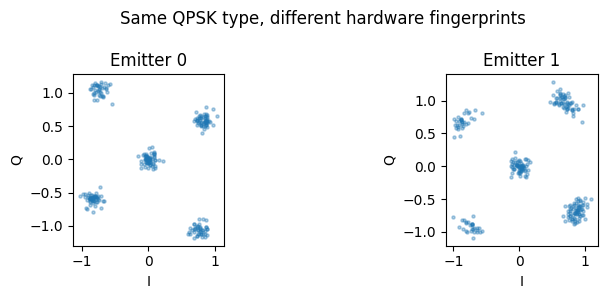

In [3]:
train_iq, train_labels = make_dataset(emitters, TRAIN_PER_EMITTER, IQ_LENGTH, TRAIN_SNR_DB, SEED + 1)
test_iq, test_labels = make_dataset(emitters, TEST_PER_EMITTER, IQ_LENGTH, TRAIN_SNR_DB, SEED + 2)
print(f'train: {train_iq.shape}, test: {test_iq.shape}')

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for emitter_id, ax in enumerate(axes):
    sample = train_iq[np.flatnonzero(train_labels == emitter_id)[0]]
    ax.scatter(sample.real, sample.imag, s=5, alpha=.35)
    ax.set(title=f'Emitter {emitter_id}', xlabel='I', ylabel='Q', aspect='equal')
fig.suptitle('Same QPSK type, different hardware fingerprints'); fig.tight_layout()

## Matched model comparison

Both models use three strided convolutions and the same embedding size. Complex parameters count as two real scalars when comparing capacity.

In [4]:
real_model = EmitterClassifier(RealEncoder(EMBEDDING_DIM), EMBEDDING_DIM, NUM_EMITTERS)
complex_model = EmitterClassifier(ComplexEncoder(EMBEDDING_DIM), EMBEDDING_DIM, NUM_EMITTERS)
pd.DataFrame([
    {'model': 'real', 'real scalar parameters': real_scalar_parameters(real_model)},
    {'model': 'complex', 'real scalar parameters': real_scalar_parameters(complex_model)},
] )

,model,real scalar parameters
0,real,34476
1,complex,34594


In [5]:
print('Real CNN')
real_history = train_classifier(real_model, train_iq, train_labels, test_iq, test_labels, device, EPOCHS, BATCH_SIZE)

Real CNN
epoch  1: loss=1.392, test_acc=0.383
epoch  2: loss=1.198, test_acc=0.479
epoch  3: loss=1.027, test_acc=0.692
epoch  4: loss=0.798, test_acc=0.742
epoch  5: loss=0.596, test_acc=0.777
epoch  6: loss=0.404, test_acc=0.873
epoch  7: loss=0.226, test_acc=0.954
epoch  8: loss=0.130, test_acc=0.965
epoch  9: loss=0.088, test_acc=0.906
epoch 10: loss=0.067, test_acc=0.975
epoch 11: loss=0.040, test_acc=0.981
epoch 12: loss=0.030, test_acc=0.983
epoch 13: loss=0.027, test_acc=0.973
epoch 14: loss=0.025, test_acc=0.975
epoch 15: loss=0.027, test_acc=0.944
epoch 16: loss=0.018, test_acc=0.973
epoch 17: loss=0.019, test_acc=0.971


In [6]:
print('Complex CNN')
complex_history = train_classifier(complex_model, train_iq, train_labels, test_iq, test_labels, device, EPOCHS, BATCH_SIZE)

Complex CNN
epoch  1: loss=1.414, test_acc=0.267
epoch  2: loss=1.356, test_acc=0.415
epoch  3: loss=1.315, test_acc=0.448
epoch  4: loss=1.269, test_acc=0.490
epoch  5: loss=1.254, test_acc=0.394
epoch  6: loss=1.188, test_acc=0.508
epoch  7: loss=1.124, test_acc=0.506
epoch  8: loss=1.094, test_acc=0.479
epoch  9: loss=1.050, test_acc=0.527
epoch 10: loss=1.016, test_acc=0.598
epoch 11: loss=0.975, test_acc=0.594
epoch 12: loss=0.907, test_acc=0.669
epoch 13: loss=0.865, test_acc=0.617
epoch 14: loss=0.853, test_acc=0.685
epoch 15: loss=0.802, test_acc=0.629
epoch 16: loss=0.771, test_acc=0.627
epoch 17: loss=0.766, test_acc=0.721


,model,accuracy,worst emitter
0,real,0.971,0.942
1,complex,0.721,0.508


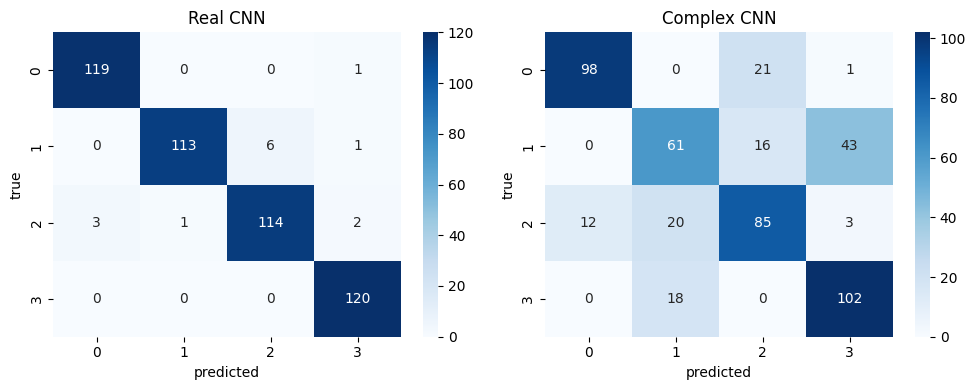

In [7]:
models = {'real': real_model, 'complex': complex_model}
results = []
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, models.items()):
    predicted = predictions(model, test_iq, device)
    matrix, per_emitter = emitter_metrics(test_labels, predicted)
    results.append({'model': name, 'accuracy': (predicted == test_labels).mean(), 'worst emitter': per_emitter.min()})
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set(title=f'{name.title()} CNN', xlabel='predicted', ylabel='true')
fig.tight_layout()
pd.DataFrame(results).round(3)

## Robustness to noise

The trained models are evaluated at new SNRs without retraining.

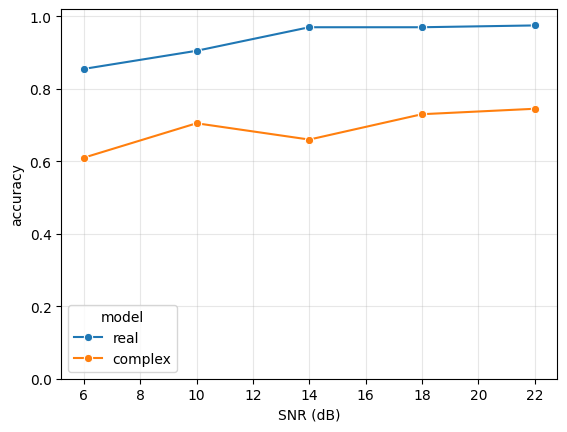

In [8]:
snr_rows = []
for snr in (6, 10, 14, 18, 22):
    sweep_iq, sweep_labels = make_dataset(emitters, 50, IQ_LENGTH, snr, SEED + 100 + snr)
    for name, model in models.items():
        score = (predictions(model, sweep_iq, device) == sweep_labels).mean()
        snr_rows.append({'SNR (dB)': snr, 'accuracy': score, 'model': name})
snr_results = pd.DataFrame(snr_rows)
sns.lineplot(snr_results, x='SNR (dB)', y='accuracy', hue='model', marker='o'); plt.ylim(0, 1.02); plt.grid(alpha=.3)

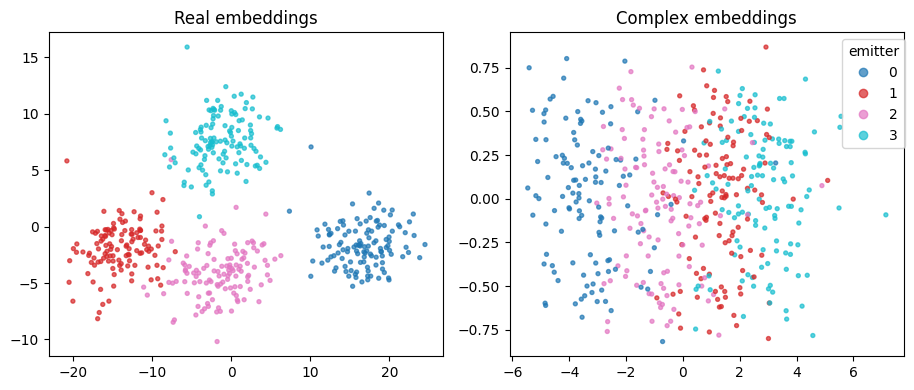

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, models.items()):
    points = PCA(2).fit_transform(embeddings(model, test_iq, device))
    scatter = ax.scatter(points[:, 0], points[:, 1], c=test_labels, s=8, cmap='tab10', alpha=.7)
    ax.set_title(f'{name.title()} embeddings')
axes[1].legend(*scatter.legend_elements(), title='emitter', bbox_to_anchor=(1.02, 1)); fig.tight_layout()

## Bonus: unknown emitters

This is intentionally only one open-set check. Two new emitters were never used for training. Higher cosine similarity to a known emitter prototype means 'known'; AUROC measures how well that separates enrolled from new emitters.

In [10]:
unknown_emitters = make_emitters(2, SEED + 999)
unknown_iq, _ = make_dataset(unknown_emitters, TEST_PER_EMITTER, IQ_LENGTH, TRAIN_SNR_DB, SEED + 1000)
open_rows = []
for name, model in models.items():
    score = open_set_auroc(
        embeddings(model, train_iq, device), train_labels,
        embeddings(model, test_iq, device), embeddings(model, unknown_iq, device),
    )
    open_rows.append({'model': name, 'unknown-emitter AUROC': score})
pd.DataFrame(open_rows).round(3)

,model,unknown-emitter AUROC
0,real,0.802
1,complex,0.640


## Takeaway

Emitter identification is possible even when every device sends the same modulation. The confusion matrices answer the core question; the SNR curve shows when the fingerprint becomes too weak to recover. The unknown-emitter result is a small diagnostic, not a full open-set system.